In [1]:
import pandas as pd
import numpy as np

# Load UCI Student Dropout & Academic Success dataset
df = pd.read_csv('../Datasets/UCI/data.csv', sep=';')

print("Dataset loaded successfully")
print("Shape:", df.shape)

# Display first 5 rows
display(df.head())

Dataset loaded successfully
Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
# Check data types
print("DATA TYPES")
print(df.dtypes)

print("\n" + "="*60)

# Check target column
print("TARGET COLUMN")
print(df['Target'].value_counts())

print("\n" + "="*60)

# Check missing values
print("MISSING VALUES")
print(df.isnull().sum().sum())

print("\n" + "="*60)

# Check duplicate rows
print("DUPLICATE ROWS")
print(df.duplicated().sum())

DATA TYPES
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gen

In [3]:
# Separate features and target

X = df.drop('Target', axis=1)
y = df['Target']

print("Features (X):", X.shape)
print("Target (y):", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.value_counts())

Features (X): (4424, 36)
Target (y): (4424,)

Feature columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Une

In [4]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (3539, 36)
Testing data shape: (885, 36)

Training target distribution:
Target
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Testing target distribution:
Target
Graduate    442
Dropout     284
Enrolled    159
Name: count, dtype: int64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include=['int64']).columns.tolist()

# Columns that represent categorical variables in the UCI dataset
categorical_columns = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance\t',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

# All remaining columns are numerical
numerical_columns = [
    col for col in X.columns if col not in categorical_columns
]

print("Number of categorical features:", len(categorical_columns))
print("Number of numerical features:", len(numerical_columns))

print("\nCategorical features:")
print(categorical_columns)

print("\nNumerical features:")
print(numerical_columns)

Number of categorical features: 18
Number of numerical features: 18

Categorical features:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

Numerical features:
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Cur

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_columns
        ),
        (
            'numerical',
            'passthrough',
            numerical_columns
        )
    ]
)

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same preprocessing
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully")

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Preprocessing completed successfully
Original training shape: (3539, 36)
Processed training shape: (3539, 251)
Original testing shape: (885, 36)
Processed testing shape: (885, 251)


In [7]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# Train the model
model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [8]:
from sklearn.metrics import accuracy_score

# Make predictions on the test data
y_pred = model.predict(X_test_processed)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2), "%")

Model Evaluation
----------------
Accuracy: 0.7582
Accuracy (%): 75.82 %


In [9]:
from sklearn.metrics import classification_report

# Generate detailed classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=['Dropout', 'Enrolled', 'Graduate']
)

print("Classification Report")
print("=====================")
print(report)

Classification Report
              precision    recall  f1-score   support

     Dropout       0.81      0.73      0.77       284
    Enrolled       0.50      0.52      0.51       159
    Graduate       0.82      0.86      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.71       885
weighted avg       0.76      0.76      0.76       885



In [13]:
import sys
print("Python being used by this notebook:")
print(sys.executable)

Python being used by this notebook:
c:\Users\Parimal R\AppData\Local\Programs\Python\Python311\python.exe


In [14]:
import sys
!{sys.executable} -m pip install seaborn


'c:\Users\Parimal' is not recognized as an internal or external command,
operable program or batch file.


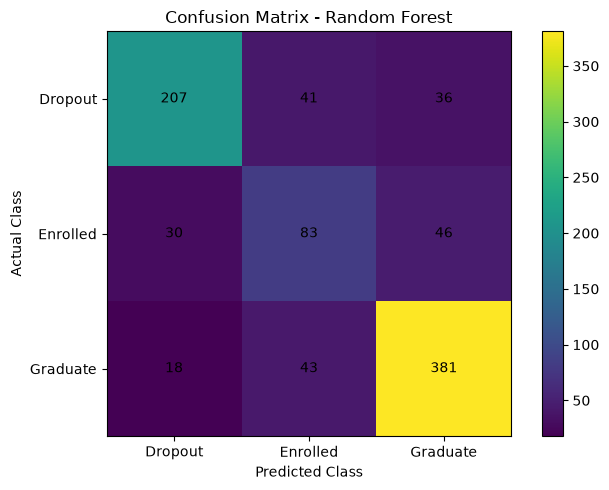

Confusion Matrix:
[[207  41  36]
 [ 30  83  46]
 [ 18  43 381]]


In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['Dropout', 'Enrolled', 'Graduate']
)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

# Add class labels
classes = ['Dropout', 'Enrolled', 'Graduate']

plt.xticks(range(3), classes)
plt.yticks(range(3), classes)

# Display numbers inside the matrix
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [18]:
import os
import joblib

# Create models folder
os.makedirs('../models', exist_ok=True)

# Save the trained Random Forest model
joblib.dump(model, '../models/random_forest_model.pkl')

# Save the preprocessing pipeline
joblib.dump(preprocessor, '../models/preprocessor.pkl')

print("Model and preprocessing pipeline saved successfully!")
print("Model file: models/random_forest_model.pkl")
print("Preprocessor file: models/preprocessor.pkl")

Model and preprocessing pipeline saved successfully!
Model file: models/random_forest_model.pkl
Preprocessor file: models/preprocessor.pkl


In [19]:
import joblib

# Load saved model and preprocessor
loaded_model = joblib.load('../models/random_forest_model.pkl')
loaded_preprocessor = joblib.load('../models/preprocessor.pkl')

# Transform test data using the loaded preprocessor
X_test_loaded = loaded_preprocessor.transform(X_test)

# Make predictions using the loaded model
loaded_predictions = loaded_model.predict(X_test_loaded)

# Check accuracy
loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("Saved model loaded successfully!")
print("Saved preprocessor loaded successfully!")
print("Predictions generated successfully!")
print("Loaded model accuracy:", round(loaded_accuracy * 100, 2), "%")

Saved model loaded successfully!
Saved preprocessor loaded successfully!
Predictions generated successfully!
Loaded model accuracy: 75.82 %
